Imports and hardware test

In [2]:
import fiftyone as fo
import fiftyone.zoo as foz
import torch
import torchvision
import os

# hardware test
print(f"GPU is ready: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU is ready: True
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 17.1 GB


Data acquisition and preparation

In [3]:
dataset_path = os.path.abspath("../../datasets/Person&Head_DataSet")
coco_json_dir = os.path.join(dataset_path, "coco_format")
print(f"Dataset path: {dataset_path}")
print(f"COCO JSON dir: {coco_json_dir}")

Dataset path: c:\Users\Dawid\Desktop\praca inżynierska\real-time-alaysis-research\datasets\Person&Head_DataSet
COCO JSON dir: c:\Users\Dawid\Desktop\praca inżynierska\real-time-alaysis-research\datasets\Person&Head_DataSet\coco_format


Global configuration

In [ ]:
# samples variables
NUMBER_OF_SAMPLES = 10000
RATIO_OF_TRAIN_SAMPLES = 0.8
NUMBER_OF_TRAIN_SAMPLES = int(NUMBER_OF_SAMPLES * RATIO_OF_TRAIN_SAMPLES)

# train variables
EPOCHS   = 80
BATCH    = 32
WORKERS  = 0
IMG_SIZE = 320
LR       = 0.0005
PATIENCE = 15

# indeks 0 = bacckground, 1 = person, 2 = head
CLASSES     = ["__background__", "Person", "Human head"]
NUM_CLASSES = len(CLASSES)  # 3

MODEL_TYPE = "mobilenet_v3_ssdlite"
VERSION    = 2
MODEL_NAME = f"{MODEL_TYPE}_V{VERSION}_S{NUMBER_OF_SAMPLES}_E{EPOCHS}_IMG{IMG_SIZE}_B{BATCH}"

print(f"Model name: {MODEL_NAME}")
print(f"Classes: {CLASSES}")

Model name: mobilenet_v3_ssdlite_V2_S10000_E80_IMG320_B32
Classes: ['__background__', 'Person', 'Human head']


Load dataset from Open Images V7 and export to COCO JSON format

In [5]:
dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="validation",
    label_types=["detections"],
    classes=["Person", "Human head"],
    max_samples=NUMBER_OF_SAMPLES,
    seed=42,
    shuffle=True
)

Only found 9381 (<10000) samples matching your requirements
Necessary images already downloaded
Existing download of split 'validation' is sufficient
Loading existing dataset 'open-images-v7-validation-10000'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


Tag dataset and export to COCO JSON format

In [ ]:
import json
import random
from pathlib import Path
from PIL import Image

# clear old tags if re-running this cell
dataset.untag_samples(dataset.distinct("tags"))

# automatically split the dataset into Train (80%) and Val (20%)
train_view = dataset.take(NUMBER_OF_TRAIN_SAMPLES, seed=42)
train_view.tag_samples("train")

val_view = dataset.exclude(train_view)
val_view.tag_samples("val")

os.makedirs(coco_json_dir, exist_ok=True)


def export_coco_json(fo_view, output_path: str, class_list: list):
    # export to COCO format, skipping samples with missing/corrupted images
    real_classes = [c for c in class_list if c != "__background__"]
    cat_id_map   = {name: i + 1 for i, name in enumerate(real_classes)}

    coco = {
        "info": {"description": "Person & Human Head — Open Images V7"},
        "categories": [{"id": cat_id_map[n], "name": n} for n in real_classes],
        "images": [],
        "annotations": []
    }

    ann_id  = 1
    skipped = 0

    for img_id, sample in enumerate(fo_view, start=1):
        try:
            img      = Image.open(sample.filepath)
            w, h     = img.size
        except Exception:
            skipped += 1
            continue

        coco["images"].append({
            "id":        img_id,
            "file_name": sample.filepath,
            "width":     w,
            "height":    h
        })

        if sample.ground_truth is None:
            continue

        for det in sample.ground_truth.detections:
            if det.label not in cat_id_map:
                continue
            bx, by, bw, bh = det.bounding_box  # normalized [0,1]
            x1     = bx * w
            y1     = by * h
            bw_abs = bw * w
            bh_abs = bh * h
            if bw_abs < 1 or bh_abs < 1:
                continue
            coco["annotations"].append({
                "id":          ann_id,
                "image_id":    img_id,
                "category_id": cat_id_map[det.label],
                "bbox":        [round(x1,2), round(y1,2), round(bw_abs,2), round(bh_abs,2)],
                "area":        round(bw_abs * bh_abs, 2),
                "iscrowd":     0
            })
            ann_id += 1

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(coco, f)

    print(f"  Zapisano: {output_path}")
    print(f"  Obrazy: {len(coco['images'])} | Adnotacje: {len(coco['annotations'])} | Pominięto: {skipped}")


print("\nEksport train...")
export_coco_json(dataset.match_tags("train"),
                 os.path.join(coco_json_dir, "train.json"), CLASSES)

print("\nEksport val...")
export_coco_json(dataset.match_tags("val"),
                 os.path.join(coco_json_dir, "val.json"), CLASSES)

print("\nEksport zakończony!")


Eksport train...
  Zapisano: c:\Users\Dawid\Desktop\praca inżynierska\real-time-alaysis-research\datasets\Person&Head_DataSet\coco_format\train.json
  Obrazy: 8000 | Adnotacje: 21649 | Pominięto: 0

Eksport val...
  Zapisano: c:\Users\Dawid\Desktop\praca inżynierska\real-time-alaysis-research\datasets\Person&Head_DataSet\coco_format\val.json
  Obrazy: 1381 | Adnotacje: 3869 | Pominięto: 0

Eksport zakończony!


Initialize model

In [ ]:
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.models.detection import SSDLite320_MobileNet_V3_Large_Weights

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load model pretrained on COCO (91 classes) to get the backbone weights
model_coco = ssdlite320_mobilenet_v3_large(
    weights=SSDLite320_MobileNet_V3_Large_Weights.COCO_V1
)

# buiuld a new model with the same backbone but custom head for our 3 classes
model = ssdlite320_mobilenet_v3_large(
    weights=None,
    weights_backbone=None,
    num_classes=NUM_CLASSES
)

# transfer backbone weights from the pretrained model to our new model
backbone_state = {
    k: v for k, v in model_coco.state_dict().items()
    if k.startswith("backbone")
}
missing, unexpected = model.load_state_dict(backbone_state, strict=False)
print(f"Loaded backbone weights from COCO model")
print(f"Missing keys: {len(missing)}")
print(f"Unexpected keys: {len(unexpected)}")

del model_coco  # release memory

model.to(DEVICE)
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"\nModel ready! Parameters: {total_params:.2f}M")
print(f"Classes:  {NUM_CLASSES} ({CLASSES})")
print(f"Device: {DEVICE}")

Załadowano wagi backbone
Brakujące klucze (głowica — OK): 84
Nieoczekiwane klucze: 0

Model gotowy! Parametry: 2.22M
Klasy:  3 (['__background__', 'Person', 'Human head'])
Device: cuda


Dataset and DataLoader

In [ ]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T


class COCODetectionDataset(Dataset):
    def __init__(self, json_path: str, img_size: int = 320, augment: bool = False):
        with open(json_path, encoding="utf-8") as f:
            coco = json.load(f)
        self.img_size  = img_size
        self.augment   = augment
        self.images    = {img["id"]: img for img in coco["images"]}
        self.anns      = {}
        for ann in coco["annotations"]:
            self.anns.setdefault(ann["image_id"], []).append(ann)
        self.ids = list(self.images.keys())
        self.transform = T.Compose([T.Resize((img_size, img_size)), T.ToTensor()])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id   = self.ids[idx]
        img_info = self.images[img_id]
        img      = Image.open(img_info["file_name"]).convert("RGB")
        ow, oh   = img.size

        # augmentation — horizontal flip (taka sama jak w YOLO: fliplr=0.5)
        flip = self.augment and random.random() > 0.5
        if flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)

        img_t  = self.transform(img)
        anns   = self.anns.get(img_id, [])
        boxes, labels = [], []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            sx, sy     = self.img_size / ow, self.img_size / oh
            x1, y1     = x * sx, y * sy
            x2, y2     = (x + w) * sx, (y + h) * sy
            if flip:
                x1, x2 = self.img_size - x2, self.img_size - x1
            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])
                labels.append(ann["category_id"])

        if boxes:
            bt = torch.tensor(boxes,  dtype=torch.float32)
            lt = torch.tensor(labels, dtype=torch.int64)
        else:
            bt = torch.zeros((0, 4), dtype=torch.float32)
            lt = torch.zeros((0,),   dtype=torch.int64)

        return img_t, {"boxes": bt, "labels": lt}


def collate_fn(batch):
    return tuple(zip(*batch))


train_dataset = COCODetectionDataset(os.path.join(coco_json_dir, "train.json"), IMG_SIZE, augment=True)
val_dataset   = COCODetectionDataset(os.path.join(coco_json_dir, "val.json"),   IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True, collate_fn=collate_fn)
print(f"Train: {len(train_dataset)} próbek | {len(train_loader)} batchy")
print(f"Val:   {len(val_dataset)} próbek | {len(val_loader)} batchy")

Train: 8000 próbek | 250 batchy
Val:   1381 próbek | 44 batchy


Start training process

In [9]:
import time
import csv
import warnings
warnings.filterwarnings("ignore")

optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=LR * 0.01)

run_dir = Path(f"runs/mobilenet/{MODEL_NAME}")
(run_dir / "weights").mkdir(parents=True, exist_ok=True)

best_val_loss  = float("inf")
patience_count = 0
history        = []

print(f"Start treningu: {MODEL_NAME}")
print(f"Epchos: {EPOCHS} | Batch: {BATCH} | LR: {LR} | Device: {DEVICE}")
print("-" * 70)

train_start = time.time()

for epoch in range(1, EPOCHS + 1):
    #Train
    model.train()
    train_loss = 0.0
    t0         = time.time()

    for images, targets in train_loader:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        losses    = sum(loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        train_loss += losses.item()

    train_loss /= len(train_loader)

    #Validation
    model.train()  # torchvision detection: loss tylko w train() mode
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images  = [img.to(DEVICE) for img in images]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            val_loss += sum(model(images, targets).values()).item()

    val_loss /= len(val_loader)
    scheduler.step()

    epoch_time = time.time() - t0
    lr_now     = optimizer.param_groups[0]["lr"]

    history.append({"epoch": epoch, "train_loss": round(train_loss, 5),
                    "val_loss": round(val_loss, 5), "lr": round(lr_now, 8)})

    print(f"Epoch {epoch:3d}/{EPOCHS} | train_loss: {train_loss:.4f} | "
          f"val_loss: {val_loss:.4f} | lr: {lr_now:.6f} | {epoch_time:.0f}s")

    # ── Zapisz modele ───────────────────────────────────────────────────────
    torch.save(model.state_dict(), run_dir / "weights" / "last.pt")
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(model.state_dict(), run_dir / "weights" / "best.pt")
        print(f"           --> New best model! val_loss={best_val_loss:.4f}")
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping po {epoch} epokach.")
            break

# Save results.csv
with open(run_dir / "results.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["epoch", "train_loss", "val_loss", "lr"])
    writer.writeheader()
    writer.writerows(history)

total_time = (time.time() - train_start) / 3600
print(f"\n{EPOCHS} epochs completed in {total_time:.3f} hours.")
print(f"Results saved to {run_dir}")
print("Training session finished!")

Start treningu: mobilenet_v3_ssdlite_V2_S10000_E80_IMG320_B32
Epoki: 80 | Batch: 32 | LR: 0.0005 | Device: cuda
----------------------------------------------------------------------
Epoch   1/80 | train_loss: 7.6693 | val_loss: 6.7637 | lr: 0.000500 | 79s
           --> Nowy best model! val_loss=6.7637
Epoch   2/80 | train_loss: 6.2643 | val_loss: 5.7951 | lr: 0.000499 | 78s
           --> Nowy best model! val_loss=5.7951
Epoch   3/80 | train_loss: 5.4936 | val_loss: 5.2583 | lr: 0.000498 | 79s
           --> Nowy best model! val_loss=5.2583
Epoch   4/80 | train_loss: 5.0737 | val_loss: 4.9531 | lr: 0.000497 | 78s
           --> Nowy best model! val_loss=4.9531
Epoch   5/80 | train_loss: 4.8006 | val_loss: 4.7466 | lr: 0.000495 | 78s
           --> Nowy best model! val_loss=4.7466
Epoch   6/80 | train_loss: 4.6103 | val_loss: 4.5939 | lr: 0.000493 | 78s
           --> Nowy best model! val_loss=4.5939
Epoch   7/80 | train_loss: 4.4615 | val_loss: 4.4837 | lr: 0.000491 | 78s
           

Training curves — Loss

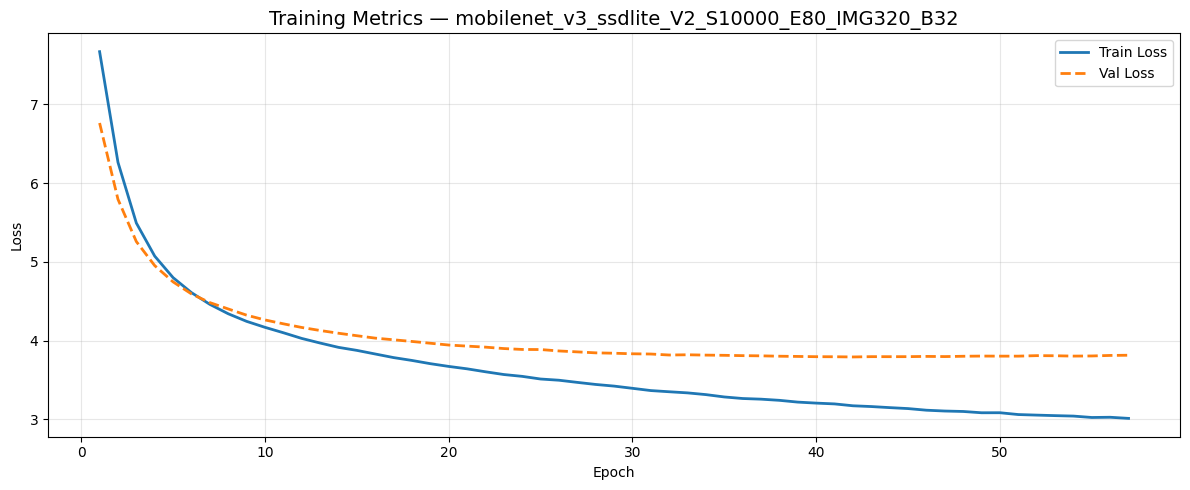

Plot saved: runs\mobilenet\mobilenet_v3_ssdlite_V2_S10000_E80_IMG320_B32\results.png


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

results_csv = run_dir / "results.csv"
df = pd.read_csv(results_csv)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["epoch"], df["train_loss"], label="Train Loss", linewidth=2)
ax.plot(df["epoch"], df["val_loss"],   label="Val Loss",   linewidth=2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Training Metrics — {MODEL_NAME}", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(run_dir / "results.png", dpi=150)
plt.show()
print(f"Plot saved: {run_dir / 'results.png'}")

Performance report — FPS CPU and GPU

In [11]:
# load the best model
model.load_state_dict(torch.load(run_dir / "weights" / "best.pt", map_location=DEVICE))
model.eval()

dummy_input = torch.zeros((1, 3, IMG_SIZE, IMG_SIZE))


def benchmark(device_str: str, n_runs: int = 100):
    dev = torch.device(device_str)
    model.to(dev)
    inp = [dummy_input.squeeze(0).to(dev)]

    # Warm-up (important for GPU)
    with torch.no_grad():
        for _ in range(10):
            _ = model(inp)

    start_time = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(inp)
    total_time = time.time() - start_time

    avg_ms = (total_time / n_runs) * 1000
    fps    = n_runs / total_time
    return round(fps, 2), round(avg_ms, 2)


print("-" * 40)
print(f"PERFORMANCE REPORT ({MODEL_TYPE})")

fps_cpu, ms_cpu = benchmark("cpu")
print(f"CPU — Average Inference Time: {ms_cpu:.2f} ms")
print(f"CPU — Throughput:             {fps_cpu:.2f} FPS")

if torch.cuda.is_available():
    fps_gpu, ms_gpu = benchmark("cuda:0")
    print(f"GPU — Average Inference Time: {ms_gpu:.2f} ms")
    print(f"GPU — Throughput:             {fps_gpu:.2f} FPS")
else:
    fps_gpu, ms_gpu = None, None

size_mb = round((run_dir / "weights" / "best.pt").stat().st_size / 1e6, 1)
print(f"Model size: {size_mb} MB")
print("-" * 40)

----------------------------------------
PERFORMANCE REPORT (mobilenet_v3_ssdlite)
CPU — Average Inference Time: 14.03 ms
CPU — Throughput:             71.26 FPS
GPU — Average Inference Time: 7.29 ms
GPU — Throughput:             137.25 FPS
Model size: 9.2 MB
----------------------------------------


Evaluation — Precision, Recall, F1 per class

In [12]:
from torchvision.ops import box_iou

model.to(DEVICE)
model.eval()

IOU_THRESH  = 0.5
CONF_THRESH = 0.5

stats = {cls_id: {"tp": 0, "fp": 0, "fn": 0} for cls_id in range(1, NUM_CLASSES)}

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)

        for pred, target in zip(preds, targets):
            keep     = pred["scores"] >= CONF_THRESH
            p_boxes  = pred["boxes"][keep].cpu()
            p_labels = pred["labels"][keep].cpu()
            t_boxes  = target["boxes"]
            t_labels = target["labels"]

            for cls_id in range(1, NUM_CLASSES):
                pb = p_boxes[p_labels == cls_id]
                tb = t_boxes[t_labels == cls_id]
                np_, nt = len(pb), len(tb)

                if nt == 0 and np_ == 0: continue
                if nt == 0: stats[cls_id]["fp"] += np_; continue
                if np_ == 0: stats[cls_id]["fn"] += nt; continue

                iou_mat    = box_iou(pb, tb)
                matched_gt = set()
                for pi in range(np_):
                    best_iou, best_gi = iou_mat[pi].max(0)
                    best_gi = best_gi.item()
                    if best_iou >= IOU_THRESH and best_gi not in matched_gt:
                        stats[cls_id]["tp"] += 1
                        matched_gt.add(best_gi)
                    else:
                        stats[cls_id]["fp"] += 1
                stats[cls_id]["fn"] += nt - len(matched_gt)

print("\n" + "=" * 60)
print(f"  Evaluation — {MODEL_NAME}")
print("=" * 60)
print(f"{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 50)

all_p, all_r, all_f1 = [], [], []
for cls_id in range(1, NUM_CLASSES):
    tp = stats[cls_id]["tp"]
    fp = stats[cls_id]["fp"]
    fn = stats[cls_id]["fn"]
    p  = tp / (tp + fp + 1e-8)
    r  = tp / (tp + fn + 1e-8)
    f1 = 2 * p * r / (p + r + 1e-8)
    all_p.append(p); all_r.append(r); all_f1.append(f1)
    print(f"{CLASSES[cls_id]:<15} {p:>10.4f} {r:>10.4f} {f1:>10.4f}")

mean_p, mean_r, mean_f1 = np.mean(all_p), np.mean(all_r), np.mean(all_f1)
print("-" * 50)
print(f"{'Mean':<15} {mean_p:>10.4f} {mean_r:>10.4f} {mean_f1:>10.4f}")
print("\n" + "=" * 60)
print("  RESULTS FOR OVERALL TABLE")
print("=" * 60)
print(f"  Model:          {MODEL_NAME}")
print(f"  Precision:      {mean_p:.4f}")
print(f"  Recall:         {mean_r:.4f}")
print(f"  F1:             {mean_f1:.4f}")
print(f"  FPS CPU:        {fps_cpu}")
print(f"  FPS GPU:        {fps_gpu}")
print(f"  Time CPU [ms]:  {ms_cpu}")
print(f"  Size [MB]:   {size_mb}")


  Evaluation — mobilenet_v3_ssdlite_V2_S10000_E80_IMG320_B32
Class            Precision     Recall         F1
--------------------------------------------------
Person              0.5930     0.1673     0.2610
Human head          0.7164     0.2876     0.4105
--------------------------------------------------
Mean                0.6547     0.2275     0.3357

  RESULTS FOR OVERALL TABLE
  Model:          mobilenet_v3_ssdlite_V2_S10000_E80_IMG320_B32
  Precision:      0.6547
  Recall:         0.2275
  F1:             0.3357
  FPS CPU:        71.26
  FPS GPU:        137.25
  Time CPU [ms]:  14.03
  Size [MB]:   9.2


In [13]:
model.eval()
model.to(DEVICE)

all_scores = []
with torch.no_grad():
    for i, (images, targets) in enumerate(val_loader):
        if i >= 20:  # próbka 20 batchy
            break
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)
        for pred in preds:
            scores = pred["scores"].cpu().numpy()
            all_scores.extend(scores.tolist())

import numpy as np
all_scores = np.array(all_scores)
print(f"Number of detections: {len(all_scores)}")
print(f"Scores > 0.5:  {(all_scores > 0.50).sum()}")
print(f"Scores > 0.3:  {(all_scores > 0.30).sum()}")
print(f"Scores > 0.2:  {(all_scores > 0.20).sum()}")
print(f"Scores > 0.1:  {(all_scores > 0.10).sum()}")
print(f"Average score:  {all_scores.mean():.4f}")
print(f"Mediana score: {np.median(all_scores):.4f}")

Number of detections: 154050
Scores > 0.5:  599
Scores > 0.3:  1205
Scores > 0.2:  2875
Scores > 0.1:  45462
Average score:  0.0897
Mediana score: 0.0734


In [14]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

model.eval()
model.to(DEVICE)

metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)

        # Format dla torchmetrics
        preds_fmt = [{
            "boxes":  p["boxes"].cpu(),
            "scores": p["scores"].cpu(),
            "labels": p["labels"].cpu()
        } for p in preds]

        tgts_fmt = [{
            "boxes":  t["boxes"].cpu(),
            "labels": t["labels"].cpu()
        } for t in targets]

        metric.update(preds_fmt, tgts_fmt)

results = metric.compute()
print(f"\nmAP@0.5:        {results['map_50']:.4f}")
print(f"mAP@0.5:0.95:   {results['map']:.4f}")
print(f"\nAP per klasa (@0.5):")
for i, ap in enumerate(results['map_per_class']):
    print(f"  {CLASSES[i+1]:<15} {ap:.4f}")


mAP@0.5:        0.3108
mAP@0.5:0.95:   0.3108

AP per klasa (@0.5):
  Person          0.2420
  Human head      0.3796


In [15]:
from torchvision.ops import box_iou
import numpy as np

model.eval()
model.to(DEVICE)
IOU_THRESH = 0.5

for CONF_THRESH in [0.5, 0.3, 0.2, 0.1, 0.05]:
    stats = {cls_id: {"tp": 0, "fp": 0, "fn": 0} for cls_id in range(1, NUM_CLASSES)}

    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(DEVICE) for img in images]
            preds  = model(images)
            for pred, target in zip(preds, targets):
                keep     = pred["scores"] >= CONF_THRESH
                p_boxes  = pred["boxes"][keep].cpu()
                p_labels = pred["labels"][keep].cpu()
                t_boxes  = target["boxes"]
                t_labels = target["labels"]
                for cls_id in range(1, NUM_CLASSES):
                    pb = p_boxes[p_labels == cls_id]
                    tb = t_boxes[t_labels == cls_id]
                    np_, nt = len(pb), len(tb)
                    if nt == 0 and np_ == 0: continue
                    if nt == 0: stats[cls_id]["fp"] += np_; continue
                    if np_ == 0: stats[cls_id]["fn"] += nt; continue
                    iou_mat = box_iou(pb, tb)
                    matched_gt = set()
                    for pi in range(np_):
                        best_iou, best_gi = iou_mat[pi].max(0)
                        best_gi = best_gi.item()
                        if best_iou >= IOU_THRESH and best_gi not in matched_gt:
                            stats[cls_id]["tp"] += 1
                            matched_gt.add(best_gi)
                        else:
                            stats[cls_id]["fp"] += 1
                    stats[cls_id]["fn"] += nt - len(matched_gt)

    all_p, all_r, all_f1 = [], [], []
    for cls_id in range(1, NUM_CLASSES):
        tp = stats[cls_id]["tp"]
        fp = stats[cls_id]["fp"]
        fn = stats[cls_id]["fn"]
        p  = tp / (tp + fp + 1e-8)
        r  = tp / (tp + fn + 1e-8)
        f1 = 2 * p * r / (p + r + 1e-8)
        all_p.append(p); all_r.append(r); all_f1.append(f1)

    print(f"CONF={CONF_THRESH:.2f} | P={np.mean(all_p):.4f} | R={np.mean(all_r):.4f} | F1={np.mean(all_f1):.4f}")

CONF=0.50 | P=0.6547 | R=0.2275 | F1=0.3357
CONF=0.30 | P=0.5263 | R=0.3241 | F1=0.4004
CONF=0.20 | P=0.3468 | R=0.4274 | F1=0.3638
CONF=0.10 | P=0.0343 | R=0.6397 | F1=0.0644
CONF=0.05 | P=0.0092 | R=0.6878 | F1=0.0182
